C:\Users\HP\AppData\Local\Temp\ipykernel_11272\2852369569.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\HP\AppData\Local\Temp\ipykernel_11272\2852369569.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tur_analizi.values, y=tur_analizi.index, palette='viridis')


Tür analizi sonuçları 'sonuclar/analiz_sonucu.txt' dosyasına eklendi.
Tür analizi grafiği 'grafikler/tur_vs_hasilat.png' olarak kaydedildi.


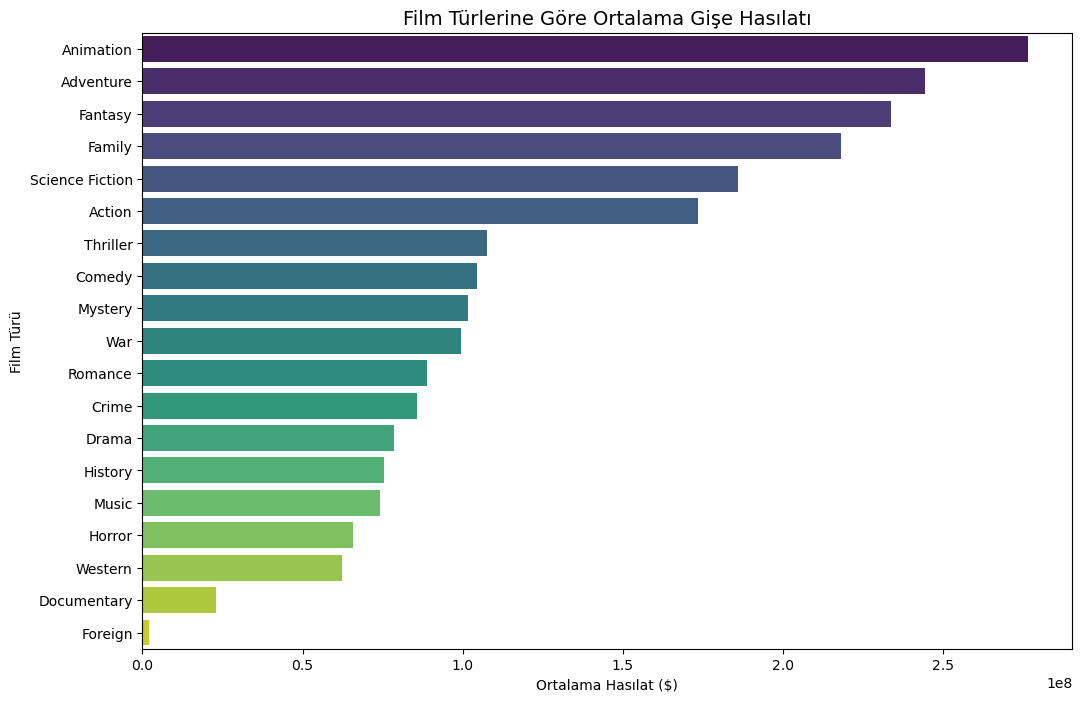

In [ ]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Klasörleri kontrol et
for folder in ['grafikler', 'sonuclar']:
    if not os.path.exists(folder): os.makedirs(folder)

# Bağlantı Bilgileri
server = r'.\SQLEXPRESS'
database = 'TMDB_MovieDB'
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    conn = pyodbc.connect(conn_str)
    
    
    query = """
    SELECT g.genre_name, m.revenue 
    FROM Movies m
    JOIN Movie_Genres mg ON m.movie_id = mg.movie_id
    JOIN Genres g ON mg.genre_id = g.genre_id
    WHERE m.revenue > 0
    """
    df = pd.read_sql(query, conn)
    conn.close()

    # Türlere göre ortalama hasılatı hesapla
    tur_analizi = df.groupby('genre_name')['revenue'].mean().sort_values(ascending=False)

    # 3. Sonuçları analiz_sonucu.txt dosyasının SONUNA EKLE (Mode 'a')
    file_path = 'sonuclar/analiz_sonucu.txt'
    with open(file_path, 'a', encoding='utf-8') as f:
        f.write("\n" + "="*60 + "\n")
        f.write("Film Türü ve Gişe Başarısı İlişkisi\n")
        f.write("Soru: Filmin türü gişe başarısını nasıl etkiliyor?\n\n")
        f.write("Türlere Göre Ortalama Hasılat (İlk 10):\n")
        for tur, deger in tur_analizi.head(10).items():
            f.write(f"- {tur}: {deger:,.0f}$\n")
        
        f.write("\nGenel Değerlendirme:\n")
        f.write("Analiz sonuçları, belirli türlerin (Örn: Macera, Animasyon, Bilim Kurgu) genellikle daha yüksek ortalama hasılat elde ettiğini göstermektedir.\n")
        f.write("Bunun temel nedeni, bu türlerin geniş kitlelere hitap etmesi ve yüksek pazarlama bütçelerine sahip olmasıdır.\n")

    print(f"Tür analizi sonuçları '{file_path}' dosyasına eklendi.")

    # 4. Görselleştirme (Bar Chart)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=tur_analizi.values, y=tur_analizi.index, palette='viridis')
    plt.title('Film Türlerine Göre Ortalama Gişe Hasılatı', fontsize=14)
    plt.xlabel('Ortalama Hasılat ($)')
    plt.ylabel('Film Türü')
    plt.savefig('grafikler/tur_vs_hasilat.png')

    print("Tür analizi grafiği 'grafikler/tur_vs_hasilat.png' olarak kaydedildi.")

except Exception as e:
    print(f"Hata oluştu: {e}")